In [1]:
import requests
import io
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

# Retrieve and post-process data
In this notebook we interrogate the chess.com API and we retrieve and post-process the data of the games of a given user.

## Parameters

In [2]:
# the general parameters we want to query
username = 'ciccio828'
years = ["2021", "2022", "2023"]
months = ["{:02d}".format(n) for n in range(1, 13)]

In [207]:
data_raw = []
for year in years:
    for month in months:
        
        # prepare query parameters
        params = {
            'username':username,
            'YYYY':year,
            'MM':month
        }
        
        # send request to the Chess.com API and get it in JSON format
        api_url = "https://api.chess.com/pub/player/{username}/games/{YYYY}/{MM}".format(**params)
        tmp = requests.get(api_url).json()
        data_raw.append(tmp)

with open('{}.pkl'.format(username), 'wb') as f:
    pickle.dump(data_raw, f)

In [3]:
# or load results
with open('../data/player_data/rugitodoleao_returns.pkl', 'rb') as f:
    data_raw = pickle.load(f)

## Post-process data

### Remove missing data and create master dataframe

In [4]:
# look inside the list of results and see if there are no games or there was an error code
data = []
for d in data_raw:
    try:
        if len(d['games']) > 0:
            data.append(d['games'])
    except KeyError:
        # this will typically happen if you asked for something weird such as the list of
        # games in the future
        continue

# create master dataframe
df = pd.concat([pd.DataFrame(d).set_index('url') for d in data])

### Determine game result in the game

In [5]:
# first, unpack the data from the dictionaries
results = {}
for color in ['white', 'black']:
    results[color] = df[color].apply(pd.Series)
    
# then, put together the results of black and white and merge back the info on the full dataframe
results = results['white'].merge(results['black'], left_index=True, right_index=True, suffixes=['_white', '_black']).\
          merge(df.drop(columns=['white', 'black']), left_index=True, right_index=True)

### User color

In [7]:
# add data on what color the username was playing
results['color'] = 'white'
results.loc[results.username_black == username, 'color'] = 'black'

### Won, lost, or draw

In [8]:
result_map = {
    'win' : 'won',
    'resigned' : 'lost',
    'timeout' : 'lost',
    'abandoned' : 'lost',
    'checkmated' : 'lost',
    'repetition': 'draw',
    'timevsinsufficient' : 'draw',
    'agreed' : 'draw',
    'stalemate' : 'draw',
    'insufficient' : 'draw'
}

other_color = {
    'white' : 'black',
    'black' : 'white'
}

def process_game_result(game):
    """This function takes a game as appears in the `results` dataframe
    and returns the result for the user"""
    
    # user color
    user_color = game.color
    
    # opponent color
    opponent_color = other_color[user_color]
    
    # this is the literal string that represents the result for username of the game
    user_result = game['result_{}'.format(user_color)]
    opponent_result = game['result_{}'.format(opponent_color)]
    
    # first, we should determine if it's a win, a lose, or a draw
    won_lost_or_draw = result_map[user_result]
    
    # then, we should determine the reason for the result:
    # if it's a win, the reason is determined by looking at the result of the opponent.
    # if it's a draw or a loss, then it's the user result
    if won_lost_or_draw == 'won':
        reason = opponent_result
    else:
        reason = user_result
        
    # now look at the rating of user
    rating = game["rating_{}".format(user_color)]
    
    return won_lost_or_draw, reason, rating

game_results = results.apply(process_game_result, axis=1).apply(pd.Series, index=['won_lost_or_draw', 'reason', 'rating'])
results = results.merge(game_results, left_index=True, right_index=True)

### Hour of the day

In [9]:
# process the hour of the day
mytz_string = 'Europe/Madrid'
ts = results.end_time.apply(lambda x : pd.Timestamp(x, unit='s', tz=mytz_string))
results['hour'] = ts.apply(lambda x : x.hour)

## Analysis

### Result by hour of the day

In [10]:
# table of won, lost, or drawn games by hour of the day
wld_hour = results.groupby('hour')['won_lost_or_draw'].value_counts().unstack().fillna(0).astype(int)

In [11]:
# number of games by hour of the day
ngames_hour = wld_hour.sum(axis=1)

# percentage of won, lost, or drawn games by hour
wld_pct_hour = wld_hour.divide(ngames_hour, axis=0) * 100

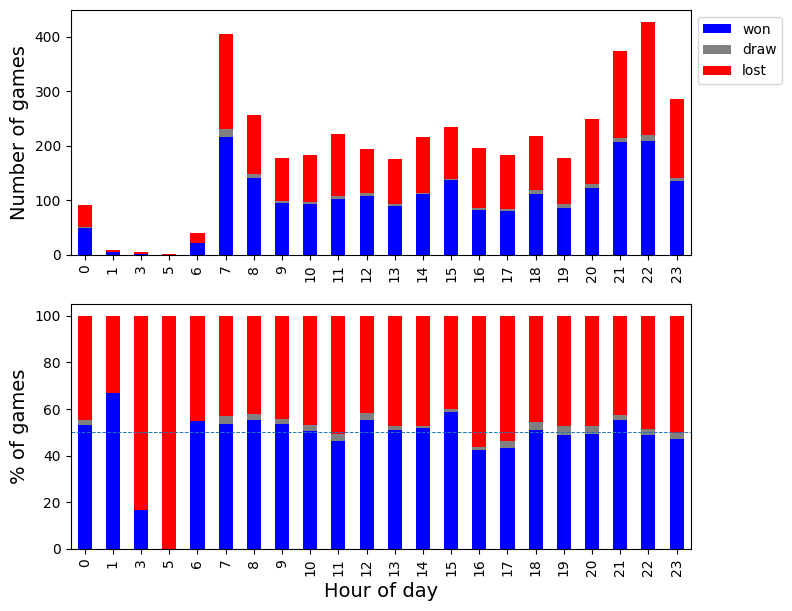

In [15]:
wld_color_map = {
    'won' : 'blue',
    'lost' : 'red',
    'draw' : 'grey'
}


# init figure
fig, axes = plt.subplots(2, 1, figsize=(8,7))

# ax 1: number
ax = axes[0]

# prepare data to plot
order_columns = ['won', 'draw', 'lost']
plot_df = wld_hour[order_columns]

# plot
plot_df.plot(kind='bar', stacked=True, color=[wld_color_map[c] for c in order_columns], ax=ax)
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_ylabel('Number of games', fontsize=14)
ax.set_xlabel('')

# ax 2: percentage
ax = axes[1]

# prepare data to plot
plot_df = wld_pct_hour[order_columns]

# plot
plot_df.plot(kind='bar', stacked=True, color=[wld_color_map[c] for c in order_columns], legend=False, ax=ax)
plt.axhline(y=50, linewidth=0.7, linestyle='--')
ax.set_xlabel('Hour of day', fontsize=14)
ax.set_ylabel('% of games', fontsize=14)

plt.show()

### Reason

In [16]:
results.groupby(['time_class', 'won_lost_or_draw']).reason.value_counts().unstack().fillna(0).astype(int)

reason                       abandoned  agreed  checkmated  insufficient  \
time_class won_lost_or_draw                                                
blitz      draw                      0      11           0            13   
           lost                     44       0         423             0   
           won                      32       0         504             0   
bullet     draw                      0       0           0             1   
           lost                      3       0          99             0   
           won                       2       0         117             0   
daily      draw                      0       1           0             0   
           lost                      0       0           7             0   
           won                       0       0          13             0   
rapid      draw                      0       1           0             1   
           lost                      0       0          11             0   
           won                       2       0          16             0   

reason                       repetition  resigned  stalemate  timeout  \
time_class won_lost_or_draw                                             
blitz      draw                      33         0         14        0   
           lost                       0       718          0      339   
           won                        0       802          0      348   
bullet     draw                       2         0          0        0   
           lost                       0        43          0      252   
           won                        0        66          0      218   
daily      draw                       0         0          0        0   
           lost                       0        34          0        5   
           won                        0        51          0        6   
rapid      draw                       2         0          0        0   
           lost                       0        31          0        2   
           won                        0        32          0        1   

reason                       timevsinsufficient  
time_class won_lost_or_draw                      
blitz      draw                              24  
           lost                               0  
           won                                0  
bullet     draw                               5  
           lost                               0  
           won                                0  
daily      draw                               0  
           lost                               0  
           won                                0  
rapid      draw                               0  
           lost                               0  
           won                                0